# Pose + bbox display (4-star sample)


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

from aitraf.data_ops.pose_and_bbox_extraction import _iter_frames
from aitraf.data_ops.schema import LabelsSchema
from aitraf.processing.utils import sample_frame_indices
from aitraf.utils import (
    POSE_DEFAULT_SKELETON,
    draw_bounding_boxes,
    draw_pose_keypoints,
    get_video_rotation_deg,
)

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
CLIPS_DIR = DATA_DIR / "clips"
LABELS_PATH = DATA_DIR / "labels.jsonl"
POSES_DIR = DATA_DIR / "poses"
BOXES_DIR = DATA_DIR / "boxes"
EXPORT_DIR = PROJECT_ROOT / "notebooks" / "data" / "pose-bbox-display"

SAMPLE_FRAMES = 5
SAMPLING_DIST = "gaussian_stochastic"

EXPORT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
RNG_SEED = 1
rng = np.random.default_rng(RNG_SEED)

labels_df = pd.read_json(LABELS_PATH, lines=True, dtype=LabelsSchema.types)
labels_df["video_id"] = labels_df["video"].apply(lambda x: Path(x).name)
four_star_df = labels_df[labels_df["execution_score"] == 4]
sample_row = four_star_df.iloc[rng.integers(len(four_star_df))]
sample_row


annotation_id                                                          688
annotator                                                                1
created_at                                2025-12-03 10:12:03.927118+00:00
execution_score                                                          4
id                                                                    1003
key_foot                                                             right
lead_time                                                           59.817
person                                                            Henrikas
trick                                                                mizou
updated_at                                2025-12-20 15:59:12.357750+00:00
video                    s3://aitraf/clips/25-12-02 21-07-51 5979-00.04...
video_id                 25-12-02 21-07-51 5979-00.04.36.392-00.04.42.1...
Name: 506, dtype: object

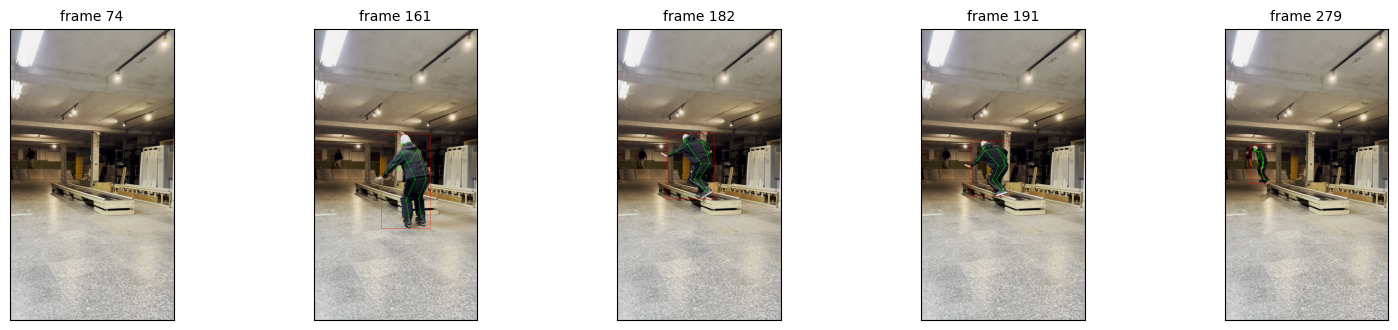

In [3]:
clip_path = CLIPS_DIR / sample_row["video_id"]
rotation_deg = get_video_rotation_deg(clip_path)
frames = list(_iter_frames(clip_path, rotation_deg))

poses = np.load(POSES_DIR / f"{clip_path.stem}.npz", allow_pickle=True)["keypoints"]
boxes = np.load(BOXES_DIR / f"{clip_path.stem}.npz", allow_pickle=True)["boxes"]

frame_indices = sample_frame_indices(
    len(frames),
    SAMPLE_FRAMES,
    SAMPLING_DIST,
    source=clip_path,
)

fig, axes = plt.subplots(
    1,
    len(frame_indices),
    figsize=(len(frame_indices) * 3.2, 3.4),
)
axes = np.atleast_1d(axes)

for idx, (ax, frame_idx) in enumerate(zip(axes, frame_indices), start=1):
    frame = frames[frame_idx]
    height, width = frame.shape[:2]
    img = Image.fromarray(frame.copy())
    draw = ImageDraw.Draw(img)

    draw_bounding_boxes(draw, boxes[frame_idx], width=width, height=height)
    draw_pose_keypoints(
        draw,
        poses[frame_idx],
        width=width,
        height=height,
        skeleton=POSE_DEFAULT_SKELETON,
    )

    img.save(EXPORT_DIR / f"{idx}.png")

    ax.imshow(img)
    ax.set_title(f"frame {frame_idx}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()
plt.show()
